In [ ]:
# GENETIC ALGORITHM

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Problem Definition

equation_inputs = np.array([4, -2, 3.5, 5, -11, -4, 7])
num_weights = len(equation_inputs)

In [ ]:
# GA Parameters

population_size = 10
num_parents = 2
num_generations = 20
mutation_rate = 0.3
fitness_history = []

In [ ]:
def initialize_population():
  return np.random.uniform(-4,4,(population_size, num_weights))

In [ ]:
def fitness(population):
  f1 = np.sum(population * equation_inputs, axis = 1)
  f2 = -np.sum(population**2, axis = 1)
  return f1 + 0.1 * f2

In [ ]:
def select_parents(population, fitness_values):
  parents = np.empty((num_parents, num_weights))
  fitness_copy = fitness_values.copy()

  for i in range(num_parents):
    idx = np.argmax(fitness_copy)
    parents[i] = population[idx]
    fitness_copy[idx] = -np.inf

  return parents

In [ ]:
def crossover(parents):
  offspring = []
  crossover_point = num_weights // 2
  for i in range(population_size - len(parents)):
    p1 = parents[i % len(parents)]
    p2 = parents[(i+1) % len(parents)]
    child = np.concatenate([p1[:crossover_point], p2[crossover_point:]])
    offspring.append(child)
  return np.array(offspring)

In [ ]:
def mutation(offspring):
  for i in range(len(offspring)):
    if np.random.rand() < mutation_rate:
      gene_idx = np.random.randint(0, num_weights)
      offspring[i][gene_idx] += np.random.uniform(-1, 1)
  return offspring

In [ ]:
def apply_constraint(population, fitness_value):
  for i in range(len(population)):
    if np.any(np.abs(population[i]) > 10):
      fitness_value[i] -= 1
  return fitness_value

In [ ]:
population = initialize_population()

for generation in range(num_generations):
  fit = fitness(population)

  fit = apply_constraint(population, fit)
  best_fit = np.max(fit)
  fitness_history.append(best_fit)
  print("Generation : ", generation, " | Best Fitness : ", round(best_fit, 4))

  parents = select_parents(population, fit)
  offspring = crossover(parents)
  offspring = mutation(offspring)

  population[:len(parents)] = parents
  population[len(parents):] = offspring

Generation :  0  | Best Fitness :  22.7926
Generation :  1  | Best Fitness :  22.7926
Generation :  2  | Best Fitness :  22.7926
Generation :  3  | Best Fitness :  27.5463
Generation :  4  | Best Fitness :  30.136
Generation :  5  | Best Fitness :  30.4848
Generation :  6  | Best Fitness :  32.3465
Generation :  7  | Best Fitness :  37.1321
Generation :  8  | Best Fitness :  40.4158
Generation :  9  | Best Fitness :  42.5648
Generation :  10  | Best Fitness :  43.8233
Generation :  11  | Best Fitness :  50.4046
Generation :  12  | Best Fitness :  50.4046
Generation :  13  | Best Fitness :  50.4046
Generation :  14  | Best Fitness :  51.4768
Generation :  15  | Best Fitness :  52.223
Generation :  16  | Best Fitness :  52.5597
Generation :  17  | Best Fitness :  52.5597
Generation :  18  | Best Fitness :  52.6977
Generation :  19  | Best Fitness :  53.8987


In [ ]:
fit = fitness(population)
best_idx = np.argmax(fit)

print("Best Solution :", population[best_idx])
print("Best Fitness :", fit[best_idx])

Best Solution : [-2.35029195  1.93591922  1.7859484   0.064679   -4.91675945 -3.66802307
 -0.44707143]
Best Fitness : 53.89873035661904


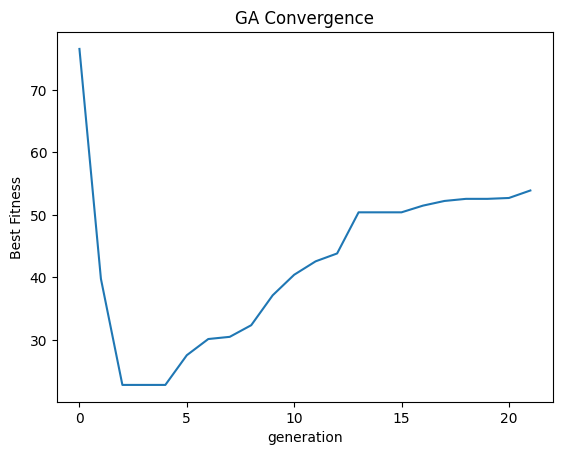

In [ ]:
plt.plot(fitness_history)
plt.xlabel("generation")
plt.ylabel("Best Fitness")
plt.title("GA Convergence")
plt.show()

In [ ]:
# Instead of picking global best, pick best from a random mini-group
def select_parents(population, fitness_values):
  parents = []
  k = 3

  for _ in range(num_parents):
    indices = np.random.choice(len(population), k, replace=False)
    best_idx = indices[np.argmax(fitness_values[indices])]
    parents.append(population[best_idx])
  return np.array(parents)

In [ ]:
if generation > 5:
  if abs(fitness_history[-1] - fitness_history[-5] < 1e-3):
    print("Early stopping triggered")